# BiLSTM with GloVe Embeddings Benchmark: Hate & Offensive Speech Classification


In [2]:
import os
import re
import time
import json
import pickle
import zipfile
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
sns.set_palette("deep")

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report
from thop import profile

device = "cuda" if torch.cuda.is_available() else "cpu"

seed = 42

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print("torch version:", torch.__version__)

torch version: 2.9.1+cu130


## Load Dataset

In [58]:
ds = load_dataset("MartynaKopyta/hate_offensive_tweets")

train_ds = ds["train"].rename_column("text_cleaned", "text")
val_ds = ds["validation"].rename_column("text_cleaned", "text")
test_ds = ds["test"].rename_column("text_cleaned", "text")

train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 23541
})

In [59]:
train_ds[0]

{'text': 'RT _Dorsey: My trash is worth more than you', 'label': 2}

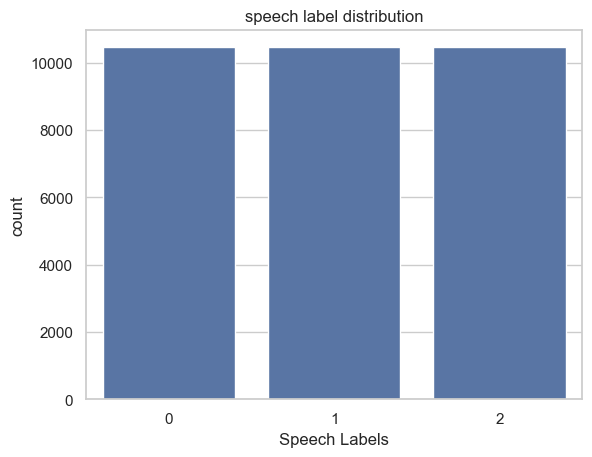

In [60]:
train = pd.DataFrame(ds["train"])
val = pd.DataFrame(ds["validation"])
test = pd.DataFrame(ds["test"])

df = pd.concat([train, val, test], ignore_index=True)

sns.countplot(data=df, x="label")
plt.title("speech label distribution")
plt.xlabel("Speech Labels")
plt.ylabel("count")
plt.show()

In [61]:
total_labels = len(set(train_ds["label"]))
print(f"Total number of labels: {total_labels}")

Total number of labels: 3


In [62]:
# label mappings
id2label = {
    0: "hate", 
    1: "offensive", 
    2: "neither",
}
label2id = {v: k for k, v in id2label.items()}

## Minimal Preprocessing + Whitespace Tokenization

In [63]:
def clean_text(text):
    # normalize whitespace
    text = str(text)
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [64]:
def tokenize_function(text):
    text = clean_text(text)
    text = text.lower()

    return re.findall(r"[a-z0-9]+(?:'[a-z]+)?", text)

In [65]:
def build_vocab(ds):
    # Build vocab from training set only
    counter = Counter()

    for text in ds["text"]:
        counter.update(tokenize_function(text))

    MIN_FREQ = 2 # min frequency for a word to be included in the vocab

    # Special tokens: PAD=0, UNK=1
    PAD_IDX = 0
    UNK_IDX = 1

    vocab = {
        "<PAD>": PAD_IDX, 
        "<UNK>": UNK_IDX
    }

    for word, count in counter.most_common():
        if count >= MIN_FREQ:
            vocab[word] = len(vocab)
    
    return vocab

In [66]:
vocab = build_vocab(train_ds)

VOCAB_SIZE = len(vocab)

print(f"Vocabulary size: {VOCAB_SIZE:,}")

Vocabulary size: 12,055


In [67]:
UNK_IDX = vocab["<UNK>"]
PAD_IDX = vocab["<PAD>"]

## Get GloVe Embeddings

In [68]:
GLOVE_DIR = "./glove"
GLOVE_ZIP = os.path.join(GLOVE_DIR, "glove.6B.zip")
GLOVE_FILE = os.path.join(GLOVE_DIR, "glove.6B.100d.txt")
EMBED_DIM = 100

os.makedirs(GLOVE_DIR, exist_ok=True)

if not os.path.exists(GLOVE_FILE):
    # download glove embeddings
    print("downloading glove")
    urllib.request.urlretrieve(
        "https://nlp.stanford.edu/data/glove.6B.zip",
        GLOVE_ZIP
    )
    
    # extract zip file
    print("extracting zip file")
    with zipfile.ZipFile(GLOVE_ZIP, "r") as zf:
        zf.extract("glove.6B.100d.txt", GLOVE_DIR)

    print("finished")
else:
    print("glove already exists")

glove already exists


In [69]:
glove_vectors = {}

# build the word vectors from glove file
with open(GLOVE_FILE, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        
        # first part is the word, rest are the vector components
        word = parts[0]

        # assign dict where word: key and vector: numpy value
        if word in vocab:
            glove_vectors[word] = np.array(parts[1:], dtype=np.float32)

In [70]:
coverage = len(glove_vectors) / VOCAB_SIZE * 100

print(f"GloVe coverage: {len(glove_vectors):,} / {VOCAB_SIZE:,} vocab words, ({coverage:.1f}%)")

GloVe coverage: 9,723 / 12,055 vocab words, (80.7%)


In [71]:
# build embedding matrix: PAD stays all-zeros
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype=np.float32)

for word, idx in vocab.items():
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
    elif idx > 1:  # not PAD or UNK
        embedding_matrix[idx] = np.random.uniform(-0.1, 0.1, EMBED_DIM) # generate random meaningless vector for OOV words

# UNK = mean of all known GloVe vectors
embedding_matrix[UNK_IDX] = np.mean(list(glove_vectors.values()), axis=0)

embedding_tensor = torch.tensor(embedding_matrix)

embedding_tensor.shape

torch.Size([12055, 100])

## Torch Dataset

In [72]:
MAX_LEN = 256  # same max_length as RoBERTa tokenizer

class CustomDataset(Dataset):
    def __init__(self, hf_split):
        # X and y pairs
        self.texts = hf_split["text"]
        self.labels = hf_split["label"]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # tokenize and convert to ids, truncating to MAX_LEN
        tokens = tokenize_function(self.texts[idx])[:MAX_LEN]
        
        # convert tokens to ids, using UNK_IDX for unknown words
        ids = [vocab.get(t, UNK_IDX) for t in tokens]

        # return tensor of ids and corresponding label
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

## Data Loaders

In [73]:
def collate_fn(batch):
    # extract texts and labels
    texts, labels = zip(*batch)
    
    # calculate max lengths of current batch
    lengths = torch.tensor([max(len(t), 1) for t in texts])

    # pad sequences to max length in batch, using PAD_IDX for padding and UNK_IDX for empty sequences
    padded = nn.utils.rnn.pad_sequence(
        [t if len(t) > 0 else torch.tensor([UNK_IDX]) for t in texts],
        batch_first=True,
        padding_value=PAD_IDX
    )

    # return padded texts, labels, and lengths
    return padded, torch.stack(labels), lengths

In [74]:
BATCH_SIZE = 16  # same as RoBERTa

train_dataset = CustomDataset(train_ds)
val_dataset = CustomDataset(val_ds)
test_dataset = CustomDataset(test_ds)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 1472 | Val batches: 368 | Test batches: 123


## BiLSTM Model

In [75]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_layers,
        num_classes,
        dropout=0.3,
        pretrained_embeddings=None,
        freeze_embeddings=False,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # assign glove weights to embedding layer
        if pretrained_embeddings is not None:
            self.embedding.weight = nn.Parameter(pretrained_embeddings)
            
        # optionally freeze embedding weights to prevent updates during training
        if freeze_embeddings:
            self.embedding.weight.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        
        # bidirectional = double hidden dim
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, lengths):
        # input_ids: (batch, seq_len)
        x = self.dropout(self.embedding(input_ids)) # (batch, seq_len, embed_dim)

        # packing makes LSTM efficiently skips PAD tokens
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)

        output, (hidden, _) = self.lstm(packed) # hidden: (num_layers*2, batch, hidden)

        # concat last forward and backward hidden states
        # hidden[-2] = last forward layer, hidden[-1] = last backward layer
        last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (batch, hidden*2)
        last_hidden = self.dropout(last_hidden)

        return self.classifier(last_hidden) # (batch, num_classes)

In [76]:
LR = 1e-3
NUM_EPOCH = 10

HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3

model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=total_labels,
    dropout=DROPOUT,
    pretrained_embeddings=embedding_tensor,
    freeze_embeddings=False,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"BiLSTM parameters: {total_params:,}")

model

BiLSTM parameters: 3,517,183


BiLSTMClassifier(
  (embedding): Embedding(12055, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=512, out_features=3, bias=True)
)

## Training

In [77]:
os.makedirs("./results/bilstm", exist_ok=True)
filename = "./results/bilstm/best_model.pt"

best_val_acc = 0.0
history = {
    "train_loss": [], 
    "val_loss": [], 
    "val_acc": [], 
    "val_f1": [],
    "val_precision": [],
    "val_recall": []
}

for epoch in range(1, NUM_EPOCH + 1):
    # train
    model.train()
    total_loss = 0

    for batch_ids, batch_labels, batch_lengths in train_loader:
        batch_ids = batch_ids.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        logits = model(batch_ids, batch_lengths)
        loss = criterion(logits, batch_labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # eval
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch_ids, batch_labels, batch_lengths in val_loader:
            batch_ids = batch_ids.to(device)
            batch_labels = batch_labels.to(device)

            logits = model(batch_ids, batch_lengths)

            val_loss += criterion(logits, batch_labels).item()

            # append true and pred
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    # calculate metrics
    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds, average="macro")
    val_precision = precision_score(all_labels, all_preds, average="macro")
    val_recall = recall_score(all_labels, all_preds, average="macro")

    scheduler.step(avg_val_loss)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["val_precision"].append(val_precision)
    history["val_recall"].append(val_recall)

    print(f"epoch {epoch:02d}/{NUM_EPOCH} | train_loss: {avg_train_loss:.4f} | val_loss: {avg_val_loss:.4f} | val_acc: {val_acc:.4f} | val_f1: {val_f1:.4f}")

    # save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), filename)
        print(f"* best model saved (val_acc={val_acc:.4f})")

print(f"\nbest val acc after training: {best_val_acc:.4f}")

epoch 01/10 | train_loss: 0.6442 | val_loss: 0.5276 | val_acc: 0.7516 | val_f1: 0.7383
* best model saved (val_acc=0.7516)
epoch 02/10 | train_loss: 0.4941 | val_loss: 0.5139 | val_acc: 0.7674 | val_f1: 0.7533
* best model saved (val_acc=0.7674)
epoch 03/10 | train_loss: 0.4368 | val_loss: 0.5037 | val_acc: 0.7708 | val_f1: 0.7617
* best model saved (val_acc=0.7708)
epoch 04/10 | train_loss: 0.3955 | val_loss: 0.5275 | val_acc: 0.7672 | val_f1: 0.7566
epoch 05/10 | train_loss: 0.3585 | val_loss: 0.5415 | val_acc: 0.7678 | val_f1: 0.7590
epoch 06/10 | train_loss: 0.3268 | val_loss: 0.6031 | val_acc: 0.7637 | val_f1: 0.7558
epoch 07/10 | train_loss: 0.2826 | val_loss: 0.6227 | val_acc: 0.7491 | val_f1: 0.7466
epoch 08/10 | train_loss: 0.2606 | val_loss: 0.7060 | val_acc: 0.7525 | val_f1: 0.7466
epoch 09/10 | train_loss: 0.2455 | val_loss: 0.7673 | val_acc: 0.7538 | val_f1: 0.7470
epoch 10/10 | train_loss: 0.2208 | val_loss: 0.8815 | val_acc: 0.7443 | val_f1: 0.7400

best val acc after tr

In [93]:
history_df = pd.DataFrame(history)

history_df.head()

,train_loss,val_loss,val_acc,val_f1,val_precision,val_recall
0,0.644238,0.527607,0.751614,0.738321,0.764564,0.754994
1,0.494105,0.513915,0.767414,0.753275,0.788494,0.770721
2,0.436785,0.503683,0.770812,0.761695,0.789273,0.774075
3,0.395450,0.527531,0.767244,0.756590,0.776245,0.769358
4,0.358463,0.541455,0.767754,0.758979,0.776911,0.770098


In [ ]:
# save using pickle
with open(os.path.join("./results/bilstm", "bilstm_metrics.pkl"), "wb") as f:
    pickle.dump(history_df, f)

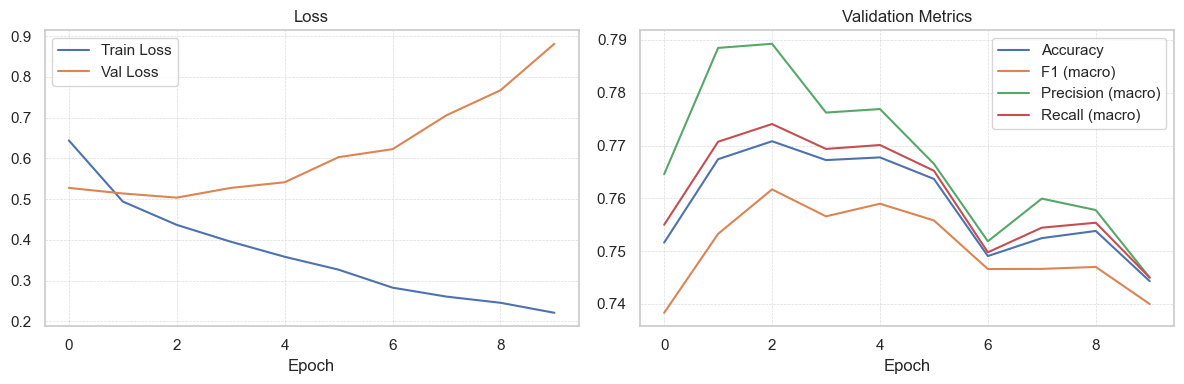

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
axes[0].legend()

axes[1].plot(history["val_acc"], label="Accuracy")
axes[1].plot(history["val_f1"],  label="F1 (macro)")
axes[1].plot(history["val_precision"], label="Precision (macro)")
axes[1].plot(history["val_recall"], label="Recall (macro)")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

## Model Evaluation


### 1. Performance Metrics

In [80]:
filename = "./results/bilstm/best_model.pt"

model.load_state_dict(torch.load(filename, map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for batch_ids, batch_labels, batch_lengths in test_loader:
        logits = model(batch_ids.to(device), batch_lengths)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch_labels.numpy())

final_acc = accuracy_score(all_labels, all_preds)
final_f1 = f1_score(all_labels, all_preds, average="macro")
final_precision = precision_score(all_labels, all_preds, average="macro")
final_recall = recall_score(all_labels, all_preds, average="macro")

print(f"Final accuracy : {final_acc:.4f}")
print(f"Final F1 (macro): {final_f1:.4f}")
print(f"Final Precision (macro): {final_precision:.4f}")
print(f"Final Recall (macro): {final_recall:.4f}")

Final accuracy : 0.7798
Final F1 (macro): 0.7723
Final Precision (macro): 0.7970
Final Recall (macro): 0.7815


In [81]:
true_labels = [id2label[label] for label in all_labels]
pred_labels = [id2label[pred] for pred in all_preds]

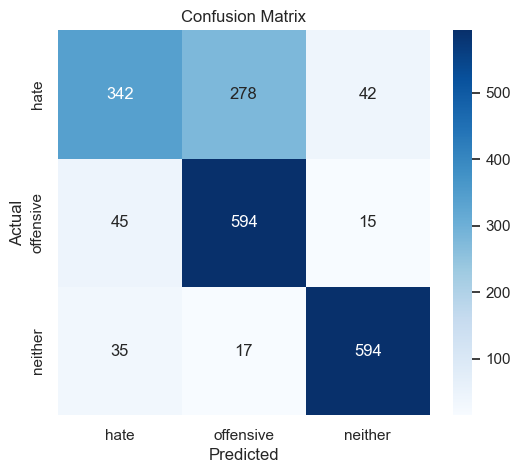

In [82]:
labels = list(id2label.values())

cm = confusion_matrix(
    true_labels,
    pred_labels,
    labels=labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [83]:
report = classification_report(true_labels, pred_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.head(total_labels + 4)

,precision,recall,f1-score,support
hate,0.810427,0.516616,0.630996,662.000000
neither,0.912442,0.919505,0.915960,646.000000
offensive,0.668166,0.908257,0.769929,654.000000
accuracy,0.779817,0.779817,0.779817,0.779817
macro avg,0.797012,0.781459,0.772295,1962.000000
weighted avg,0.796596,0.779817,0.771133,1962.000000


### 2. Compute Metrics

In [84]:
def get_model_size_mb(model):
    param_size = 0

    for param in model.parameters():
        param_size += param.nelement() * param.element_size()

    buffer_size = 0

    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    size_mb = (param_size + buffer_size) / 1024**2

    return size_mb

In [85]:
model_size = get_model_size_mb(model)
print(f"Model size: {model_size:.2f} MB")

Model size: 13.42 MB


In [86]:
example_text = "haha i know this is a test sample, but you are so stupid"

tokens = tokenize_function(example_text)[:MAX_LEN]

ids = [vocab.get(t, UNK_IDX) for t in tokens]

# handle empty text edge case
if len(ids) == 0:
    ids = [UNK_IDX]

# convert to tensor
input_ids = torch.tensor([ids], dtype=torch.long).to(device)
lengths = torch.tensor([len(ids)], dtype=torch.long).to(device)

model.eval()

macs, params = profile(
    model,
    inputs=(input_ids, lengths),
    verbose=False
)

gflops = macs * 2 / 1e9

print(f"GFLOPs: {gflops:.4f}")

GFLOPs: 0.0603


In [87]:
def prepare_bilstm_input(text, device="cuda", max_length=128):
    tokens = tokenize_function(text)[:max_length]
    ids = [vocab.get(t, UNK_IDX) for t in tokens]

    if len(ids) == 0:
        ids = [UNK_IDX]

    length = len(ids)

    # pad to fixed max_length for fair latency measurement
    if len(ids) < max_length:
        ids = ids + [PAD_IDX] * (max_length - len(ids))

    input_ids = torch.tensor([ids], dtype=torch.long).to(device)
    lengths = torch.tensor([length], dtype=torch.long).to(device)

    return input_ids, lengths


def measure_bilstm_latency(model, text, device="cuda", max_length=128, warmup=10, runs=100):
    model.to(device)
    model.eval()

    input_ids, lengths = prepare_bilstm_input(
        text=text,
        device=device,
        max_length=max_length
    )

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(input_ids, lengths)

        if device == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        for _ in range(runs):
            _ = model(input_ids, lengths)

        if device == "cuda":
            torch.cuda.synchronize()

        end = time.perf_counter()

    latency_ms = ((end - start) / runs) * 1000
    return latency_ms

In [88]:
latency = measure_bilstm_latency(
    model=model,
    text=example_text,
    device=device,
    max_length=128
)

print(f"Inference latency: {latency:.2f} ms/sample")

Inference latency: 0.97 ms/sample


## Save Model & Vocab

In [89]:
with open("./results/bilstm/vocab.json", "w") as f:
    json.dump(vocab, f)

with open("./results/bilstm/id2label.json", "w") as f:
    json.dump(id2label, f)

model_config = {
    "vocab_size": VOCAB_SIZE,
    "embed_dim": EMBED_DIM,
    "hidden_dim": HIDDEN_DIM,
    "num_layers": NUM_LAYERS,
    "num_classes": total_labels,
    "dropout": DROPOUT,
}
with open("./results/bilstm/config.json", "w") as f:
    json.dump(model_config, f)

## Inference Example

In [90]:
with open("./results/bilstm/vocab.json") as f: vocab = json.load(f)
with open("./results/bilstm/id2label.json") as f: id2label = json.load(f)
with open("./results/bilstm/config.json") as f: cfg = json.load(f)

inference_model = BiLSTMClassifier(
    vocab_size=cfg["vocab_size"],
    embed_dim=cfg["embed_dim"],
    hidden_dim=cfg["hidden_dim"],
    num_layers=cfg["num_layers"],
    num_classes=cfg["num_classes"],
    dropout=cfg["dropout"],
).to(device)

model_dict = torch.load("./results/bilstm/best_model.pt", map_location=device)

inference_model.load_state_dict(model_dict)
inference_model.eval()

BiLSTMClassifier(
  (embedding): Embedding(12055, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=512, out_features=3, bias=True)
)

In [91]:
def predict(text):
    tokens = tokenize_function(text)[:MAX_LEN]
    ids = torch.tensor([[vocab.get(t, UNK_IDX) for t in tokens]], dtype=torch.long).to(device)
    length = torch.tensor([len(tokens)])

    with torch.no_grad():
        logits = inference_model(ids, length)
        probs = torch.softmax(logits, dim=1)
        pred_id = probs.argmax(dim=1).item()

    return {
        "label": id2label[str(pred_id)], 
        "score": probs[0, pred_id].item(),
    }

In [92]:
print("input text:", example_text)
predict(example_text)

input text: haha i know this is a test sample, but you are so stupid


{'label': 'hate', 'score': 0.5296532511711121}